In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_style("whitegrid")

In [2]:
survey = pd.read_csv("../data/processed/survey_clean.csv")
survey.head()


,country_of_residence,area_type,age_group,annual_income_range_(in_local_currency_equivalent)_please_refer_your_country's_avg._national_income,occupation,do_you_currently_own_a_vehicle,what_type_of_vehicle_do_you_currently_own,"if_you_own_an_ev,_mention_your_ev_brand","if_you_do_not_own_an_ev,_are_you_considering_buying_one_in_the_next_2–3_years",average_daily_driving_distance,...,would_declining_ev_sales_reduce_your_confidence_in_an_ev_company’s_future,ev_motivation_score,ev_barrier_score,factor_price,factor_range,factor_brand,factor_design,factor_charging,ev_adoption_score,ev_readiness_score
0,India,3,4.0,Above average national income,Business owner / Self-employed,1.0,Petrol / Diesel,none,1.0,3,...,1,1.0,4.430597,1,0,0,0,0,-3.428571,1.0
1,India,3,4.0,Above average national income,Salaried employee,1.0,Petrol / Diesel,none,1.0,2,...,5,NaN,4.681731,1,1,1,1,1,NaN,NaN
2,India,3,4.0,Above average national income,Business owner / Self-employed,1.0,Petrol / Diesel,none,0.5,1,...,1,NaN,1.000000,0,1,0,1,1,NaN,NaN
3,India,1,4.0,Above average national income,Salaried employee,1.0,Petrol / Diesel,none,1.0,3,...,3,NaN,3.398054,0,1,0,0,0,NaN,NaN
4,India,3,NaN,Prefer not to say,Retired,1.0,Petrol / Diesel,none,0.5,1,...,3,NaN,NaN,1,1,0,1,1,NaN,NaN


In [3]:
survey.info()
survey.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 325 entries, 0 to 324
Data columns (total 41 columns):
 #   Column                                                                                               Non-Null Count  Dtype  
---  ------                                                                                               --------------  -----  
 0   country_of_residence                                                                                 325 non-null    object 
 1   area_type                                                                                            325 non-null    int64  
 2   age_group                                                                                            313 non-null    float64
 3   annual_income_range_(in_local_currency_equivalent)_please_refer_your_country's_avg._national_income  325 non-null    object 
 4   occupation                                                                                           325 non-n

,area_type,age_group,do_you_currently_own_a_vehicle,"if_you_do_not_own_an_ev,_are_you_considering_buying_one_in_the_next_2–3_years",average_daily_driving_distance,lower_running_cost,environmental_benefits,government_incentives___subsidies,rising_fuel_prices,advanced_technology_&_features,...,would_declining_ev_sales_reduce_your_confidence_in_an_ev_company’s_future,ev_motivation_score,ev_barrier_score,factor_price,factor_range,factor_brand,factor_design,factor_charging,ev_adoption_score,ev_readiness_score
count,325.000000,313.000000,325.000000,325.000000,325.000000,179.000000,187.000000,187.000000,186.000000,186.000000,...,325.000000,187.000000,313.000000,325.000000,325.000000,325.000000,325.000000,325.000000,179.000000,179.000000
mean,2.440000,2.792332,0.910769,0.581538,2.024615,3.770950,3.631016,3.069519,3.951613,4.064516,...,3.563077,3.676860,3.624405,0.612308,0.760000,0.393846,0.547692,0.587692,-0.020218,1.089562
std,0.720254,1.131571,0.285516,0.368887,0.892014,1.169867,1.370857,1.379762,1.384401,1.325887,...,1.214568,1.021502,0.950222,0.487975,0.427742,0.489355,0.498488,0.493009,1.172642,0.272729
min,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-3.428571,1.000000
25%,2.000000,2.000000,1.000000,0.500000,1.000000,3.000000,3.000000,2.000000,3.000000,4.000000,...,3.000000,3.128101,2.991005,0.000000,1.000000,0.000000,0.000000,0.000000,-0.571429,1.000000
50%,3.000000,3.000000,1.000000,0.500000,2.000000,4.000000,4.000000,3.000000,5.000000,5.000000,...,4.000000,3.933620,3.776974,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000
75%,3.000000,4.000000,1.000000,1.000000,3.000000,5.000000,5.000000,4.000000,5.000000,5.000000,...,5.000000,4.381735,4.368545,1.000000,1.000000,1.000000,1.000000,1.000000,0.714286,1.000000
max,3.000000,4.000000,1.000000,1.000000,4.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.857143,2.724152


In [4]:
numeric_features = survey.select_dtypes(include=['int64','float64'])
numeric_features = numeric_features.fillna(numeric_features.mean())

In [5]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_features)

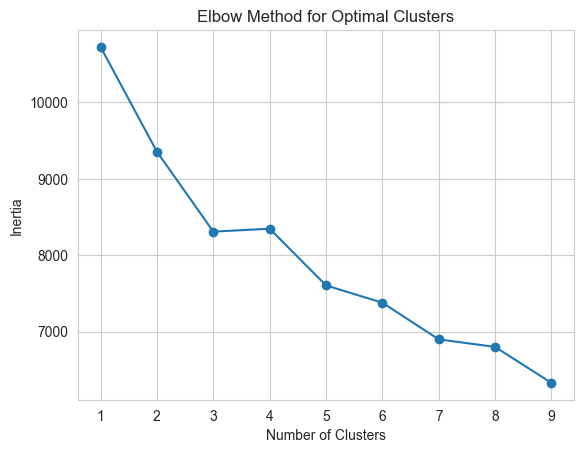

In [6]:
inertia = []
for k in range(1,10):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(scaled_data)
    inertia.append(model.inertia_)
plt.plot(range(1,10), inertia, marker='o')
plt.title("Elbow Method for Optimal Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42)
survey['cluster'] = kmeans.fit_predict(scaled_data)
survey.head()

,country_of_residence,area_type,age_group,annual_income_range_(in_local_currency_equivalent)_please_refer_your_country's_avg._national_income,occupation,do_you_currently_own_a_vehicle,what_type_of_vehicle_do_you_currently_own,"if_you_own_an_ev,_mention_your_ev_brand","if_you_do_not_own_an_ev,_are_you_considering_buying_one_in_the_next_2–3_years",average_daily_driving_distance,...,ev_motivation_score,ev_barrier_score,factor_price,factor_range,factor_brand,factor_design,factor_charging,ev_adoption_score,ev_readiness_score,cluster
0,India,3,4.0,Above average national income,Business owner / Self-employed,1.0,Petrol / Diesel,none,1.0,3,...,1.0,4.430597,1,0,0,0,0,-3.428571,1.0,2
1,India,3,4.0,Above average national income,Salaried employee,1.0,Petrol / Diesel,none,1.0,2,...,NaN,4.681731,1,1,1,1,1,NaN,NaN,1
2,India,3,4.0,Above average national income,Business owner / Self-employed,1.0,Petrol / Diesel,none,0.5,1,...,NaN,1.000000,0,1,0,1,1,NaN,NaN,0
3,India,1,4.0,Above average national income,Salaried employee,1.0,Petrol / Diesel,none,1.0,3,...,NaN,3.398054,0,1,0,0,0,NaN,NaN,1
4,India,3,NaN,Prefer not to say,Retired,1.0,Petrol / Diesel,none,0.5,1,...,NaN,NaN,1,1,0,1,1,NaN,NaN,1


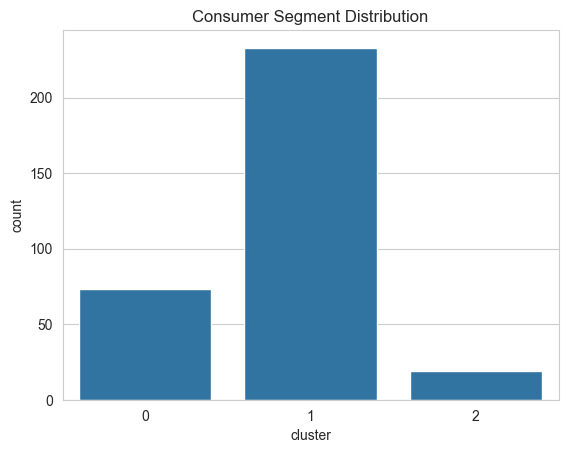

In [8]:
sns.countplot(x='cluster', data=survey)
plt.title("Consumer Segment Distribution")
plt.show()

In [9]:
pca = PCA(n_components=2)
components = pca.fit_transform(scaled_data)
survey['pca1'] = components[:,0]
survey['pca2'] = components[:,1]

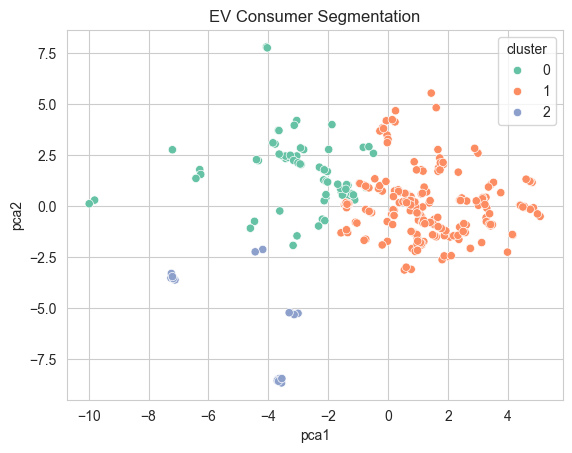

In [10]:
sns.scatterplot(
    x='pca1',
    y='pca2',
    hue='cluster',
    data=survey,
    palette='Set2'
)
plt.title("EV Consumer Segmentation")
plt.show()

In [11]:
numeric_cols = survey.select_dtypes(include=['int64','float64']).columns
cluster_profile = survey.groupby('cluster')[numeric_cols].mean()
cluster_profile

,area_type,age_group,do_you_currently_own_a_vehicle,"if_you_do_not_own_an_ev,_are_you_considering_buying_one_in_the_next_2–3_years",average_daily_driving_distance,lower_running_cost,environmental_benefits,government_incentives___subsidies,rising_fuel_prices,advanced_technology_&_features,...,ev_barrier_score,factor_price,factor_range,factor_brand,factor_design,factor_charging,ev_adoption_score,ev_readiness_score,pca1,pca2
cluster,,,,,,,,,,,,,,,,,,,,,
0,2.712329,2.865672,0.917808,0.609589,1.890411,3.305556,3.694444,3.000000,3.805556,3.194444,...,2.418917,0.219178,0.739726,0.164384,0.356164,0.356164,0.884921,1.186122,-2.938639,1.697964
1,2.351931,2.696035,0.901288,0.547210,2.030043,4.053030,3.946970,3.189394,4.404580,4.702290,...,4.012947,0.703863,0.819742,0.489270,0.643777,0.699571,0.054916,1.075252,1.291880,-0.055699
2,2.473684,3.684211,1.000000,0.894737,2.473684,1.909091,1.315789,2.368421,1.105263,1.315789,...,3.736669,1.000000,0.105263,0.105263,0.105263,0.105263,-2.225564,1.000000,-4.551972,-5.840710


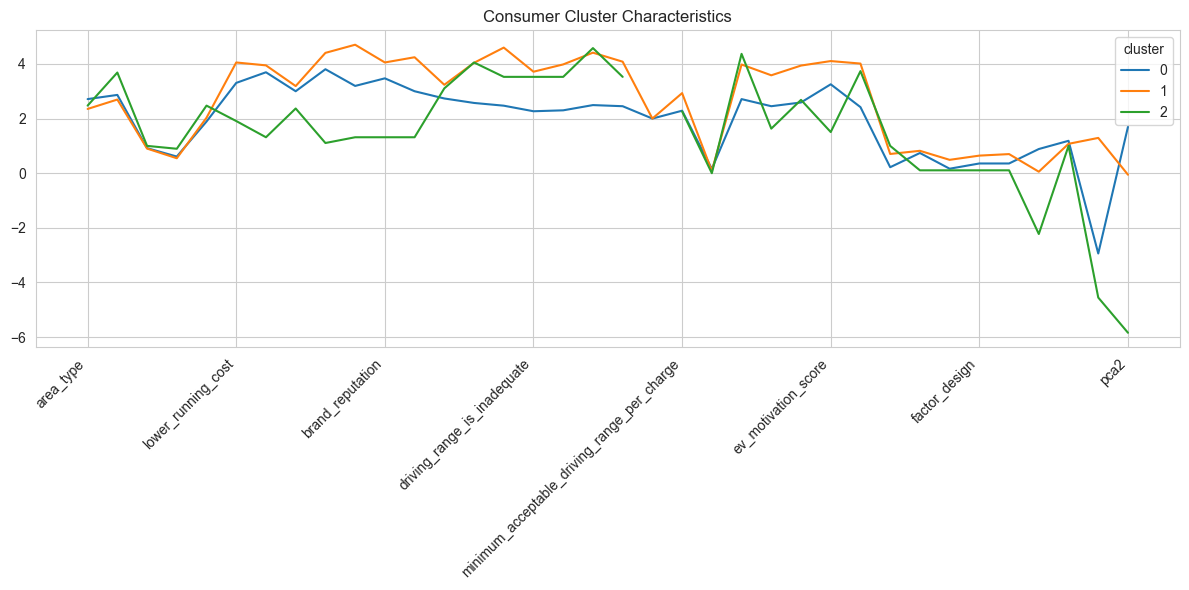

In [12]:
cluster_profile.T.plot(figsize=(12,6))
plt.title("Consumer Cluster Characteristics")
plt.xticks(rotation=45, ha='right')   # rotate labels
plt.tight_layout()                    # adjust spacing
plt.show()

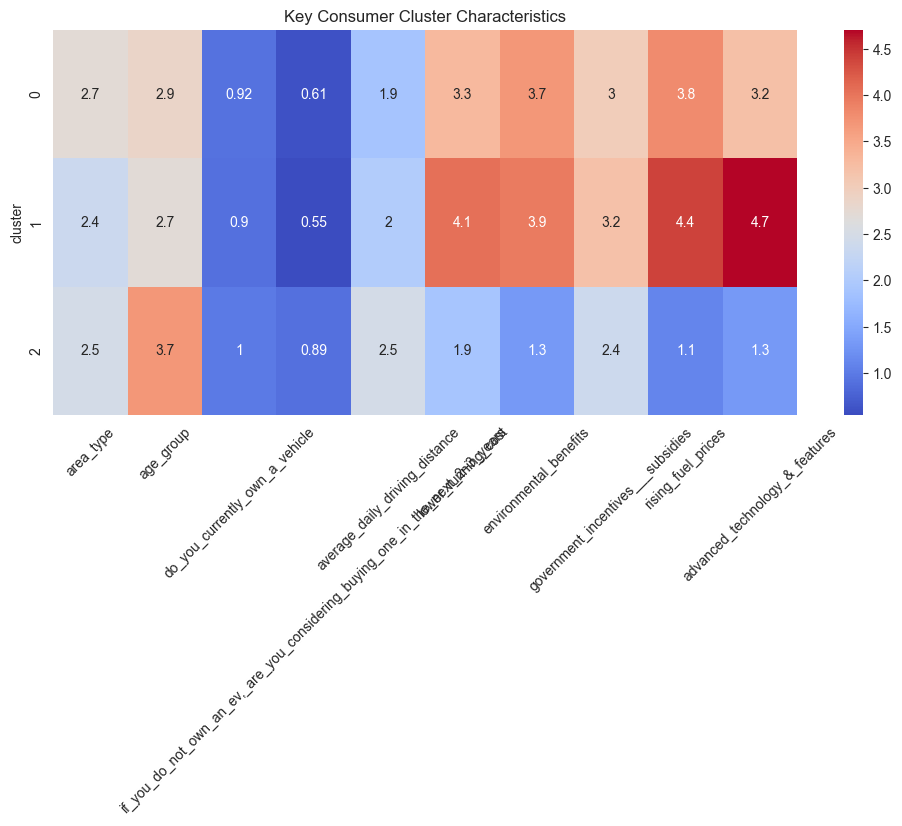

In [13]:
important_features = cluster_profile.columns[:10]
plt.figure(figsize=(12,5))
sns.heatmap(
    cluster_profile[important_features],
    cmap="coolwarm",
    annot=True
)
plt.title("Key Consumer Cluster Characteristics")
plt.xticks(rotation=45)
plt.show()

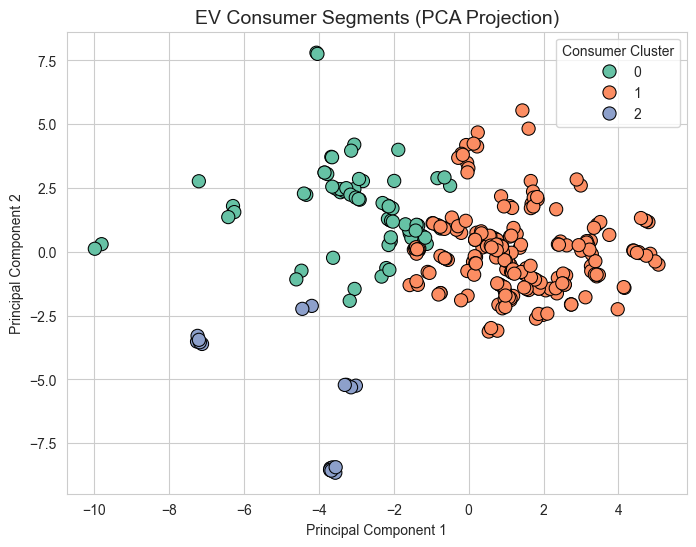

In [14]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='pca1',
    y='pca2',
    hue='cluster',
    palette='Set2',
    data=survey,
    s=90,
    edgecolor='black'
)
plt.title("EV Consumer Segments (PCA Projection)", fontsize=14)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Consumer Cluster")
plt.grid(True)
plt.show()

## Random Forest Classification for EV Purchase Prediction

Predicting consumer purchase intent based on survey features using Random Forest Classifier.

In [15]:
# Create binary target variable: High-value consumers (Cluster 0 = likely buyers, others = less likely)
# This assumes Cluster 0 represents high-intent consumers
target = (survey['cluster'] == 0).astype(int)

survey['purchase_intent'] = target

print(f"Class Distribution:\n{target.value_counts()}")
print(f"\nPercentage of High-Value Consumers: {target.mean()*100:.2f}%")

Class Distribution:
cluster
0    252
1     73
Name: count, dtype: int64

Percentage of High-Value Consumers: 22.46%


In [16]:
# Prepare features and target
X = scaled_data  # Use scaled numeric features
y = target      # Binary purchase intent

# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # Ensure balanced class distribution
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")
print(f"Training set class distribution:\n{np.bincount(y_train)}")

Training set size: 260
Testing set size: 65
Training set class distribution:
[202  58]


In [17]:
# Train Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=100,      # Number of trees
    max_depth=10,          # Maximum tree depth
    min_samples_split=5,   # Minimum samples to split a node
    random_state=42,
    n_jobs=-1              # Use all available processors
)

rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Random Forest Model Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

Random Forest Model Accuracy: 0.9846 (98.46%)


Classification Report:
              precision    recall  f1-score   support

  Low Intent       0.98      1.00      0.99        50
 High Intent       1.00      0.93      0.97        15

    accuracy                           0.98        65
   macro avg       0.99      0.97      0.98        65
weighted avg       0.98      0.98      0.98        65


Confusion Matrix:
[[50  0]
 [ 1 14]]


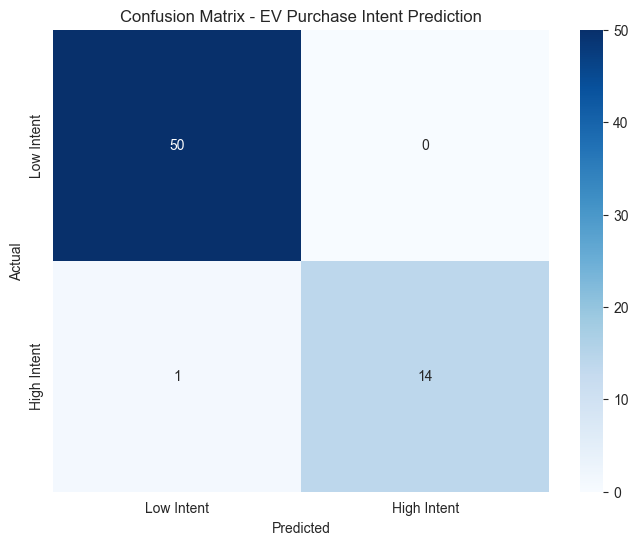

In [18]:
# Detailed model evaluation
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Low Intent', 'High Intent']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print(f"\nConfusion Matrix:\n{cm}")

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=['Low Intent', 'High Intent'],
    yticklabels=['Low Intent', 'High Intent']
)
plt.title("Confusion Matrix - EV Purchase Intent Prediction")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

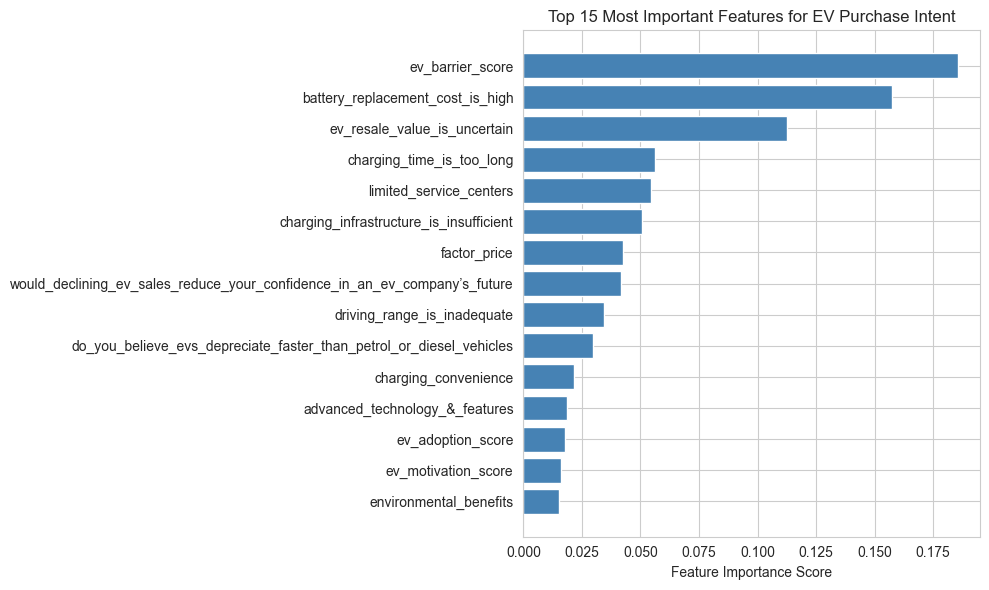


Top 10 Most Important Features:
ev_barrier_score: 0.1857
battery_replacement_cost_is_high: 0.1575
ev_resale_value_is_uncertain: 0.1126
charging_time_is_too_long: 0.0561
limited_service_centers: 0.0546
charging_infrastructure_is_insufficient: 0.0508
factor_price: 0.0425
would_declining_ev_sales_reduce_your_confidence_in_an_ev_company’s_future: 0.0418
driving_range_is_inadequate: 0.0346
do_you_believe_evs_depreciate_faster_than_petrol_or_diesel_vehicles: 0.0296


In [19]:
# Feature Importance Analysis
feature_importance = rf_model.feature_importances_

# Get top 15 most important features
top_indices = np.argsort(feature_importance)[-15:]

feature_names = numeric_features.columns

plt.figure(figsize=(10, 6))
plt.barh(
    range(len(top_indices)), 
    feature_importance[top_indices],
    color='steelblue'
)
plt.yticks(range(len(top_indices)), [feature_names[i] for i in top_indices])
plt.xlabel("Feature Importance Score")
plt.title("Top 15 Most Important Features for EV Purchase Intent")
plt.tight_layout()
plt.show()

# Print top features
print("\nTop 10 Most Important Features:")
for idx, importance in sorted(enumerate(feature_importance), key=lambda x: x[1], reverse=True)[:10]:
    print(f"{feature_names[idx]}: {importance:.4f}")

In [20]:
# Get prediction probabilities for better insights
y_pred_proba = rf_model.predict_proba(X_test)

# Create results dataframe
results_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred,
    'Confidence_Low_Intent': y_pred_proba[:, 0],
    'Confidence_High_Intent': y_pred_proba[:, 1]
})

# Show some sample predictions
print("Sample Predictions with Confidence Scores:")
print(results_df.head(10))

# Model Summary
print("\n=== Random Forest Model Summary ===")
print(f"Total Test Samples: {len(y_test)}")
print(f"Correct Predictions: {(y_test == y_pred).sum()}")
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Model Parameters:")
print(f"  - Number of trees: 100")
print(f"  - Max depth: 10")
print(f"  - Min samples split: 5")

Sample Predictions with Confidence Scores:
     Actual  Predicted  Confidence_Low_Intent  Confidence_High_Intent
239       0          0               1.000000                0.000000
59        0          0               1.000000                0.000000
157       1          1               0.186405                0.813595
203       0          0               0.946310                0.053690
190       0          0               0.727810                0.272190
226       0          0               0.991250                0.008750
129       0          0               0.988000                0.012000
92        0          0               0.990000                0.010000
308       0          0               0.921333                0.078667
150       0          0               0.955000                0.045000

=== Random Forest Model Summary ===
Total Test Samples: 65
Correct Predictions: 64
Accuracy: 98.46%
Model Parameters:
  - Number of trees: 100
  - Max depth: 10
  - Min samples split: 5
